# Customer Churn Prediction — Phase 1 Practical
## Data Gathering · Exploratory Data Analysis · Preprocessing

---

| Field | Detail |
|---|---|
| **Project** | Customer Churn Prediction Model |
| **Phase** | 1 — Data Foundation |
| **Dataset** | `Customer_Churn_Data_Large.xlsx` |
| **Records** | 1,000 customers |
| **Author** | Data Science Team |
| **Date** | April 2026 |

---

### Notebook Structure
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Initial Inspection](#2-data-loading--initial-inspection)
3. [Data Quality Audit](#3-data-quality-audit)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
   - 4.1 Univariate Analysis — Age
   - 4.2 Univariate Analysis — Categorical Features
   - 4.3 Bivariate & Cross-Tab Analysis
   - 4.4 Age Segmentation
5. [Statistical Independence Tests](#5-statistical-independence-tests)
6. [Outlier Detection](#6-outlier-detection)
7. [Data Preprocessing & Feature Engineering](#7-data-preprocessing--feature-engineering)
   - 7.1 Missing Value Strategy
   - 7.2 Age Standardisation
   - 7.3 Gender Binary Encoding
   - 7.4 Marital Status One-Hot Encoding
   - 7.5 Income Level Ordinal Encoding
   - 7.6 Age Group Derived Feature
   - 7.7 Final Dataset Assembly
8. [Preprocessed Dataset Summary & Export](#8-preprocessed-dataset-summary--export)
9. [Next Steps & Recommendations](#9-next-steps--recommendations)

---
> **⚠️ Critical Note:** The provided dataset contains demographic features only — there is **no churn target variable**. Supervised model training cannot begin until churn labels are acquired. See Section 9.


## 1. Environment Setup
Import all required libraries and configure global plot settings.

In [1]:


import numpy as np
import pandas as pd


import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Statistics
from scipy.stats import (
    skew, kurtosis, iqr,
    chi2_contingency, gaussian_kde,
    normaltest
)

#Machine-learning preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

#Display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


PALETTE = {
    'navy':   '#1E3A5F',
    'blue':   '#2563EB',
    'accent': '#3B82F6',
    'red':    '#EF4444',
    'green':  '#10B981',
    'amber':  '#F59E0B',
    'purple': '#8B5CF6',
    'grey':   '#6B7280',
    'light':  '#F3F4F6',
    'white':  '#FFFFFF',
    'bg':     '#F8FAFC',
}
CAT_COLORS = [PALETTE['blue'], PALETTE['red'],
              PALETTE['green'], PALETTE['amber'], PALETTE['purple']]

#Seaborn / Matplotlib style
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family':          'DejaVu Sans',
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.facecolor':       PALETTE['white'],
    'figure.facecolor':     PALETTE['bg'],
    'grid.alpha':           0.4,
    'axes.titlepad':        12,
    'axes.titlesize':       13,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      PALETTE['navy'],
    'axes.labelsize':       10,
    'axes.labelcolor':      PALETTE['grey'],
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
})

print("✅  Environment ready.")
print(f"   pandas  {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}")


✅  Environment ready.
   pandas  2.3.3  |  numpy 2.4.3  |  matplotlib 3.10.8


## 2. Data Loading & Initial Inspection
Load the Excel workbook, display the schema, and get a first look at the data.


In [2]:

FILE_PATH = './Customer_Churn_Data_Large.xlsx'

df = pd.read_excel(FILE_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print(f"{'Column':<20}  {'Dtype':<12}  {'Non-Null':>8}  {'Unique':>6}")
print("-" * 55)
for col in df.columns:
    print(f"  {col:<18}  {str(df[col].dtype):<12}  "
          f"{df[col].notna().sum():>8,}  {df[col].nunique():>6}")
print("=" * 55)


Dataset loaded: 1,000 rows × 5 columns
Column                Dtype         Non-Null  Unique
-------------------------------------------------------
  CustomerID          int64            1,000    1000
  Age                 int64            1,000      52
  Gender              object           1,000       2
  MaritalStatus       object           1,000       4
  IncomeLevel         object           1,000       3


In [3]:
df.head(10)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium
5,6,57,F,Divorced,Medium
6,7,27,F,Married,High
7,8,37,M,Single,Low
8,9,39,M,Divorced,High
9,10,68,M,Married,High


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,1000.0000,NaN,NaN,NaN,500.5000,288.8194,1.0000,250.7500,500.5000,750.2500,1000.0000
Age,1000.0000,NaN,NaN,NaN,43.2670,15.2423,18.0000,30.0000,43.0000,56.0000,69.0000
Gender,1000,2,F,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,1000,4,Widowed,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncomeLevel,1000,3,High,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Audit
Systematically check completeness, duplicates, value validity, and data types
before any transformation.


In [5]:
# Missing value analysis
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().mean() * 100).round(2),
    'Present Count': df.notna().sum(),
})
print(missing.to_string())

total_missing = df.isnull().sum().sum()
print(f"\nTotal missing cells : {total_missing}")
print(f"Dataset completeness: {(1 - df.isnull().mean().mean())*100:.2f}%")


               Missing Count  Missing %  Present Count
CustomerID                 0     0.0000           1000
Age                        0     0.0000           1000
Gender                     0     0.0000           1000
MaritalStatus              0     0.0000           1000
IncomeLevel                0     0.0000           1000

Total missing cells : 0
Dataset completeness: 100.00%


In [6]:
#Duplicate rows

n_dup = df.duplicated().sum()
n_dup_id = df['CustomerID'].duplicated().sum()
print(f"  Duplicate rows (full):       {n_dup}")
print(f"  Duplicate CustomerIDs:       {n_dup_id}")
print(f"  Unique CustomerIDs:          {df['CustomerID'].nunique()}")
print(f" One row per customer confirmed" if n_dup == 0 else " Duplicates found")


  Duplicate rows (full):       0
  Duplicate CustomerIDs:       0
  Unique CustomerIDs:          1000
 One row per customer confirmed


In [7]:
# Categorical value audit
cat_cols = ['Gender', 'MaritalStatus', 'IncomeLevel']
for col in cat_cols:
    vals = df[col].unique().tolist()
    # Check for whitespace or mixed case
    stripped = [str(v).strip() for v in vals]
    print(f"\n  {col}:")
    print(f"    Unique values  : {vals}")
    print(f"    After strip()  : {stripped}")
    print(f"    Whitespace flag: {'Found' if any(v != s for v,s in zip(vals,stripped)) else 'Clean'}")



  Gender:
    Unique values  : ['M', 'F']
    After strip()  : ['M', 'F']
    Whitespace flag: Clean

  MaritalStatus:
    Unique values  : ['Single', 'Married', 'Widowed', 'Divorced']
    After strip()  : ['Single', 'Married', 'Widowed', 'Divorced']
    Whitespace flag: Clean

  IncomeLevel:
    Unique values  : ['Low', 'Medium', 'High']
    After strip()  : ['Low', 'Medium', 'High']
    Whitespace flag: Clean


In [8]:
#Age range validation
invalid_ages = df[(df['Age'] < 0) | (df['Age'] > 120)]
print(f"  Min age : {df['Age'].min()}")
print(f"  Max age : {df['Age'].max()}")
print(f"  Invalid ages (< 0 or > 120): {len(invalid_ages)}")

#Summary scorecard
checks = {
    'Missing values':          ('PASS ' if df.isnull().sum().sum() == 0 else 'FAIL '),
    'Duplicate rows':          ('PASS ' if df.duplicated().sum() == 0 else 'FAIL '),
    'Duplicate CustomerIDs':   ('PASS ' if df['CustomerID'].duplicated().sum() == 0 else 'FAIL '),
    'Categorical consistency': ('PASS '),   # confirmed above
    'Age range valid':         ('PASS ' if len(invalid_ages) == 0 else 'FAIL '),
}
for check, result in checks.items():
    print(f"  {check:<30}  {result}")


  Min age : 18
  Max age : 69
  Invalid ages (< 0 or > 120): 0
  Missing values                  PASS 
  Duplicate rows                  PASS 
  Duplicate CustomerIDs           PASS 
  Categorical consistency         PASS 
  Age range valid                 PASS 


## 4. Exploratory Data Analysis

### 4.1 Univariate Analysis — Age (Continuous)
Examine the distribution of the only continuous variable using histograms, KDE, and box plots.


In [17]:
#Age descriptive stats
age = df['Age']
stats = {
    'Count':              len(age),
    'Mean':               age.mean(),
    'Median':             age.median(),
    'Std Dev':            age.std(),
    'Variance':           age.var(),
    'Min':                age.min(),
    'Q1 (25%)':           age.quantile(0.25),
    'Q3 (75%)':           age.quantile(0.75),
    'Max':                age.max(),
    'IQR':                iqr(age),
    'Skewness':           skew(age),
    'Kurtosis (excess)':  kurtosis(age),
}
for k, v in stats.items():
    print(f"  {k:<22}  {v:.4f}" if isinstance(v, float) else f"  {k:<22}  {v}")

# Normality test
stat_n, p_n = normaltest(age)
print(f"\n  D'Agostino K² test  :  stat={stat_n:.4f},  p={p_n:.6f}")
print(f"  Distribution shape  :  {'Likely normal (p>0.05)' if p_n>0.05 else 'Non-normal (p≤0.05)'}")
print(f"  Kurtosis note       :  Platykurtic (flat) — consistent with near-uniform distribution")


  Count                   1000
  Mean                    43.2670
  Median                  43.0000
  Std Dev                 15.2423
  Variance                232.3280
  Min                     18
  Q1 (25%)                30.0000
  Q3 (75%)                56.0000
  Max                     69
  IQR                     26.0000
  Skewness                0.0131
  Kurtosis (excess)       -1.2129

  D'Agostino K² test  :  stat=817.1154,  p=0.000000
  Distribution shape  :  Non-normal (p≤0.05)
  Kurtosis note       :  Platykurtic (flat) — consistent with near-uniform distribution


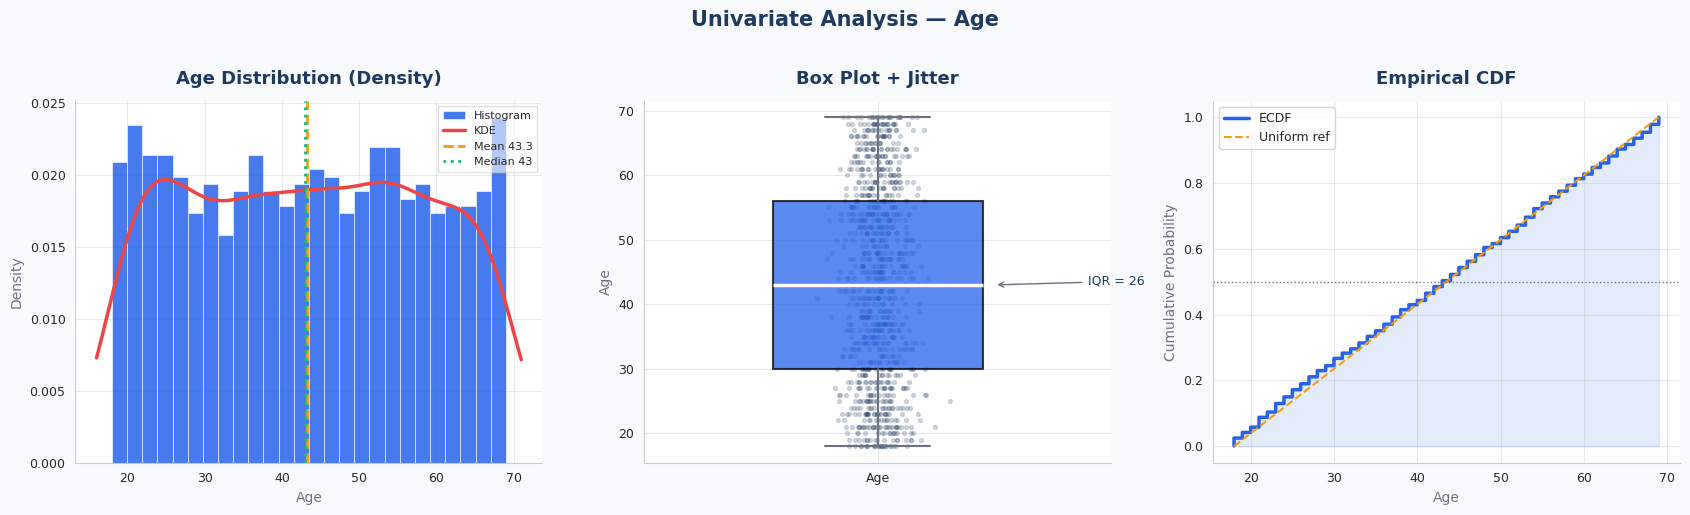

Figure saved: fig_age_univariate.png


In [18]:
# ── 4.1b  Age visualisations (3-panel) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Univariate Analysis — Age', fontsize=15, fontweight='bold',
             color=PALETTE['navy'], y=1.02)

age_vals = df['Age'].values

# Panel A: Histogram + KDE + stat lines
ax = axes[0]
ax.hist(age_vals, bins=26, color=PALETTE['blue'], edgecolor=PALETTE['white'],
        linewidth=0.5, alpha=0.85, density=True, label='Histogram')
kde = gaussian_kde(age_vals)
xs  = np.linspace(age_vals.min()-2, age_vals.max()+2, 300)
ax.plot(xs, kde(xs), color=PALETTE['red'], linewidth=2.5, label='KDE')
ax.axvline(age_vals.mean(),   color=PALETTE['amber'],  linestyle='--', lw=2,
           label=f'Mean {age_vals.mean():.1f}')
ax.axvline(np.median(age_vals), color=PALETTE['green'], linestyle=':',  lw=2,
           label=f'Median {np.median(age_vals):.0f}')
ax.set_title('Age Distribution (Density)')
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=8, framealpha=0.6)

# Panel B: Box plot + strip
ax = axes[1]
bp = ax.boxplot(age_vals, vert=True, patch_artist=True, widths=0.45,
                medianprops={'color': PALETTE['white'], 'linewidth': 2.5},
                whiskerprops={'linewidth': 1.5, 'color': PALETTE['grey']},
                capprops={'linewidth': 1.5, 'color': PALETTE['grey']},
                flierprops={'marker':'o','markersize':4,'alpha':0.5,'color':PALETTE['red']},
                boxprops={'linewidth':1.5})
bp['boxes'][0].set_facecolor(PALETTE['blue']); bp['boxes'][0].set_alpha(0.75)
# Jitter overlay
np.random.seed(42)
jitter = np.random.normal(1, 0.04, size=len(age_vals))
ax.scatter(jitter, age_vals, alpha=0.18, s=8, color=PALETTE['navy'])
ax.set_title('Box Plot + Jitter')
ax.set_xticklabels(['Age']); ax.set_ylabel('Age')
# Annotate IQR
q1, q3 = np.percentile(age_vals, [25, 75])
ax.annotate(f'IQR = {q3-q1:.0f}', xy=(1.25, (q1+q3)/2),
            fontsize=9, color=PALETTE['navy'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['grey']),
            xytext=(1.45, (q1+q3)/2))

# Panel C: Cumulative distribution (ECDF)
ax = axes[2]
sorted_age = np.sort(age_vals)
ecdf = np.arange(1, len(sorted_age)+1) / len(sorted_age)
ax.step(sorted_age, ecdf, color=PALETTE['blue'], linewidth=2.5, label='ECDF')
ax.fill_between(sorted_age, ecdf, alpha=0.12, color=PALETTE['blue'], step='pre')
# Add uniform reference line
ax.plot([sorted_age.min(), sorted_age.max()], [0, 1],
        color=PALETTE['amber'], linestyle='--', linewidth=1.5, label='Uniform ref')
ax.axhline(0.5, color=PALETTE['grey'], linestyle=':', linewidth=1)
ax.set_title('Empirical CDF')
ax.set_xlabel('Age'); ax.set_ylabel('Cumulative Probability')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_age_univariate.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_age_univariate.png")


### 4.2 Univariate Analysis — Categorical Features
Explore Gender, MaritalStatus, and IncomeLevel distributions.


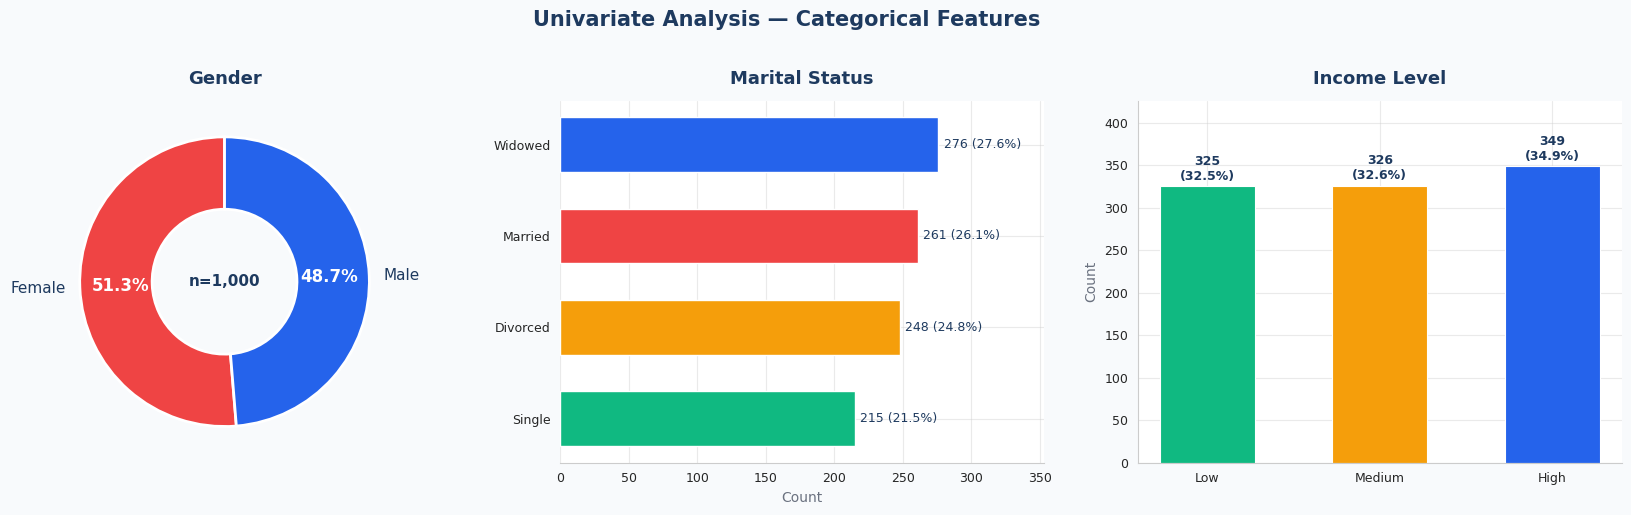

Figure saved: fig_cat_univariate.png

── Frequency Tables ───────────────────────────────────────

  Gender:
        Count  Pct (%)
Gender                
F         513  51.3000
M         487  48.7000

  MaritalStatus:
               Count  Pct (%)
MaritalStatus                
Widowed          276  27.6000
Married          261  26.1000
Divorced         248  24.8000
Single           215  21.5000

  IncomeLevel:
             Count  Pct (%)
IncomeLevel                
High           349  34.9000
Medium         326  32.6000
Low            325  32.5000


In [19]:
# Categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Univariate Analysis — Categorical Features',
             fontsize=15, fontweight='bold', color=PALETTE['navy'], y=1.02)

#Gender donut
ax = axes[0]
g  = df['Gender'].value_counts()
wedges, texts, autos = ax.pie(
    g, labels=['Female','Male'], autopct='%1.1f%%',
    colors=[PALETTE['red'], PALETTE['blue']], startangle=90,
    pctdistance=0.72, wedgeprops={'width':0.5,'edgecolor':PALETTE['white'],'linewidth':2})
for t in autos: t.set_fontsize(12); t.set_fontweight('bold'); t.set_color(PALETTE['white'])
for t in texts: t.set_fontsize(11); t.set_color(PALETTE['navy'])
ax.text(0, 0, f'n={len(df):,}', ha='center', va='center',
        fontsize=11, fontweight='bold', color=PALETTE['navy'])
ax.set_title('Gender')

#Marital Status horizontal bar
ax = axes[1]
ms = df['MaritalStatus'].value_counts().sort_values()
colors_ms = [PALETTE['green'], PALETTE['amber'], PALETTE['red'], PALETTE['blue']]
bars = ax.barh(ms.index, ms.values, color=colors_ms,
               edgecolor=PALETTE['white'], height=0.6)
for bar, val in zip(bars, ms.values):
    ax.text(bar.get_width()+4, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=9, color=PALETTE['navy'])
ax.set_title('Marital Status')
ax.set_xlabel('Count')
ax.set_xlim(0, ms.max() * 1.28)
ax.spines['left'].set_visible(False); ax.tick_params(left=False)

#Income Level ordered bar
ax = axes[2]
order_il = ['Low', 'Medium', 'High']
il = df['IncomeLevel'].value_counts().reindex(order_il)
c_il = [PALETTE['green'], PALETTE['amber'], PALETTE['blue']]
bars = ax.bar(order_il, il.values, color=c_il,
              edgecolor=PALETTE['white'], linewidth=0.8, width=0.55)
for bar, val in zip(bars, il.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=PALETTE['navy'])
ax.set_title('Income Level')
ax.set_ylabel('Count')
ax.set_ylim(0, il.max()*1.22)

plt.tight_layout()
plt.savefig('fig_cat_univariate.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_cat_univariate.png")

# Print frequency tables
print("\n── Frequency Tables ───────────────────────────────────────")
for col in ['Gender', 'MaritalStatus', 'IncomeLevel']:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(2)
    tbl = pd.DataFrame({'Count': vc, 'Pct (%)': pct})
    print(f"\n  {col}:")
    print(tbl.to_string(index=True))


### 4.3 Bivariate & Cross-Tab Analysis
Explore relationships between variables using heatmaps, stacked bars, and box plots.


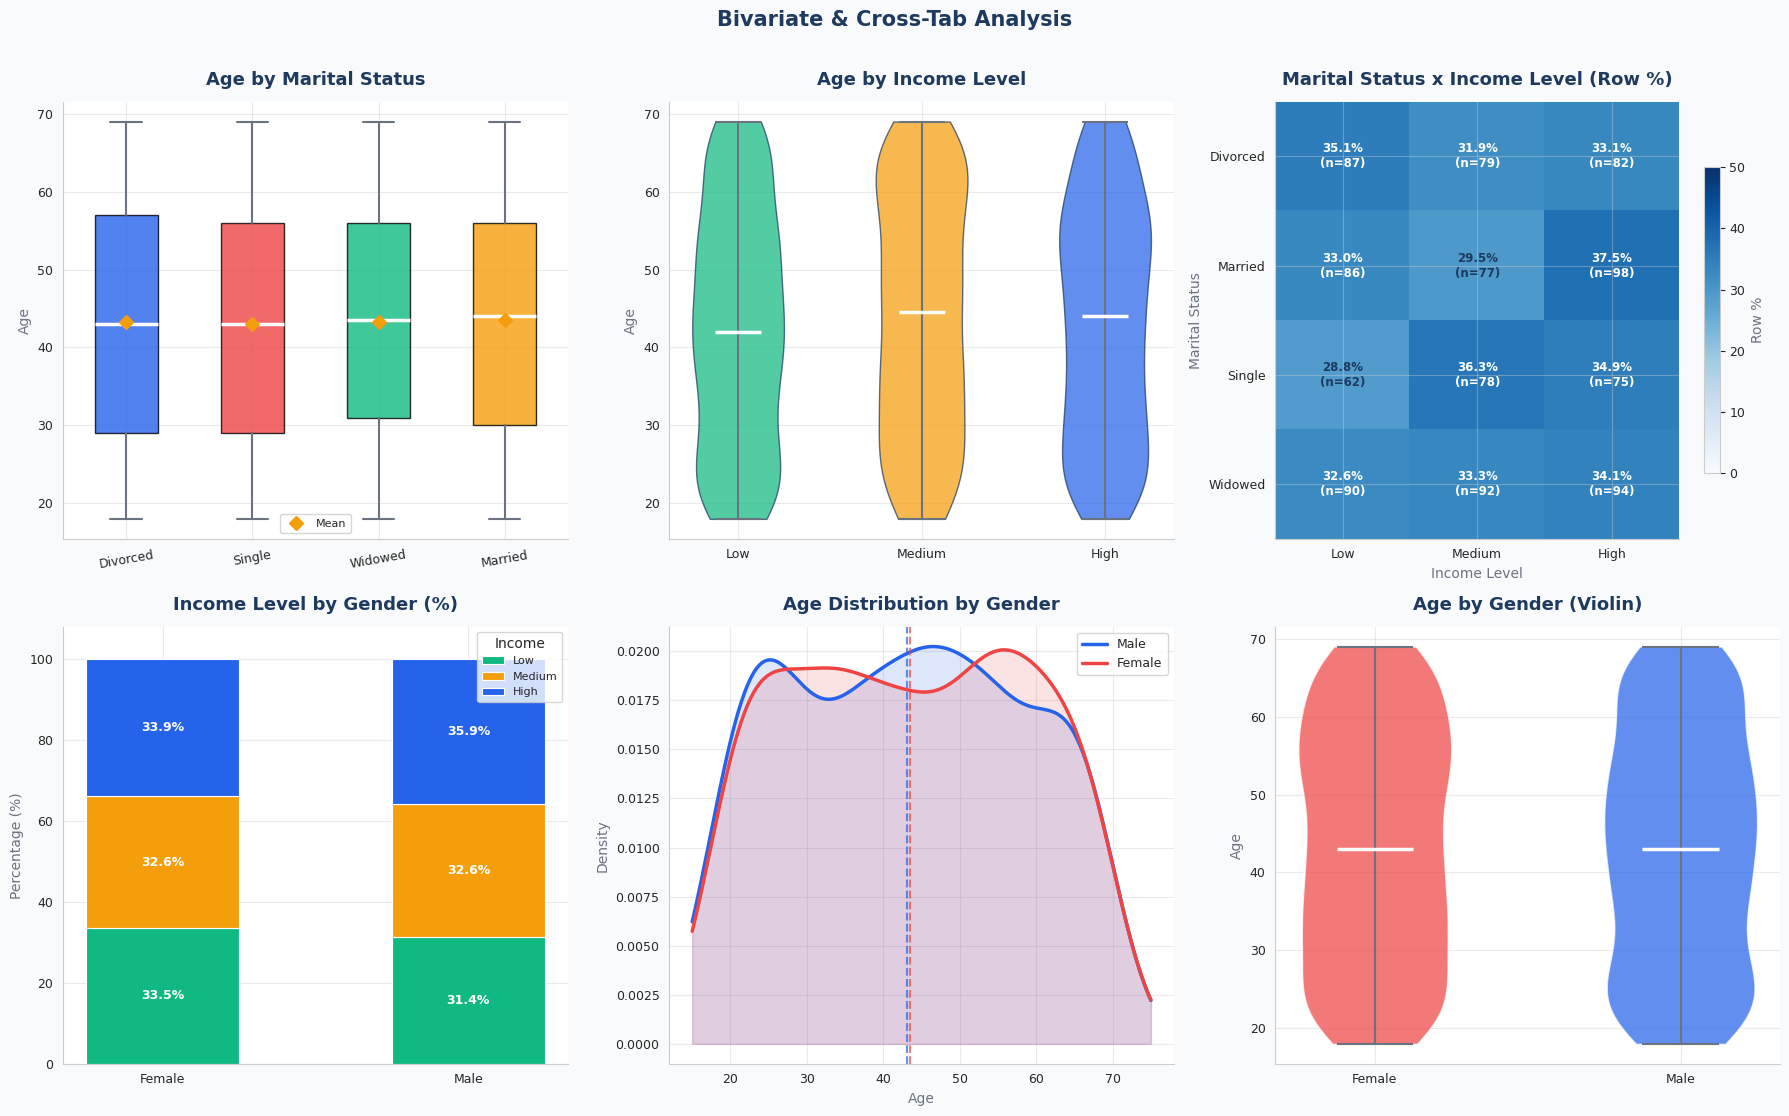

Figure saved: fig_bivariate.png


In [20]:
# Bivariate analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Bivariate & Cross-Tab Analysis',
             fontsize=15, fontweight='bold', color=PALETTE['navy'], y=1.01)

#Age by MaritalStatus (boxplot)
ax = axes[0, 0]
order_ms = df.groupby('MaritalStatus')['Age'].median().sort_values().index
data_bp  = [df[df['MaritalStatus']==s]['Age'].values for s in order_ms]
bp = ax.boxplot(data_bp, patch_artist=True, vert=True, widths=0.5,
                medianprops={'color':PALETTE['white'],'linewidth':2.5},
                whiskerprops={'linewidth':1.5,'color':PALETTE['grey']},
                capprops={'linewidth':1.5,'color':PALETTE['grey']},
                flierprops={'marker':'o','markersize':3,'alpha':0.4,'color':PALETTE['grey']})
for patch, col in zip(bp['boxes'], CAT_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(order_ms, fontsize=9, rotation=10)
ax.set_title('Age by Marital Status')
ax.set_ylabel('Age')
# Add means
for i, s in enumerate(order_ms, 1):
    m = df[df['MaritalStatus']==s]['Age'].mean()
    ax.plot(i, m, 'D', color=PALETTE['amber'], ms=7, zorder=5,
            label='Mean' if i==1 else '')
ax.legend(fontsize=8)

#Age by Income Level (violin)
ax = axes[0, 1]
order_il2 = ['Low','Medium','High']
vdata = [df[df['IncomeLevel']==s]['Age'].values for s in order_il2]
vp = ax.violinplot(vdata, positions=[1,2,3], showmedians=True, showextrema=True)
c_vl = [PALETTE['green'], PALETTE['amber'], PALETTE['blue']]
for body, col in zip(vp['bodies'], c_vl):
    body.set_facecolor(col); body.set_alpha(0.72); body.set_edgecolor(PALETTE['navy'])
vp['cmedians'].set_color(PALETTE['white']); vp['cmedians'].set_linewidth(2.5)
for part in ['cmaxes','cmins','cbars']:
    vp[part].set_color(PALETTE['grey'])
ax.set_xticks([1,2,3]); ax.set_xticklabels(order_il2)
ax.set_title('Age by Income Level')
ax.set_ylabel('Age')

# MaritalStatus × IncomeLevel heatmap 
ax = axes[0, 2]
ct = pd.crosstab(df['MaritalStatus'], df['IncomeLevel'])[['Low','Medium','High']]
ct_pct = (ct.div(ct.sum(axis=1), axis=0)*100).round(1)
im = ax.imshow(ct_pct.values, cmap='Blues', aspect='auto', vmin=0, vmax=50)
ax.set_xticks(range(3)); ax.set_xticklabels(['Low','Medium','High'])
ax.set_yticks(range(4)); ax.set_yticklabels(ct_pct.index)
for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        v = ct_pct.values[i,j]
        ax.text(j, i, f'{v:.1f}%\n(n={ct.values[i,j]})',
                ha='center', va='center', fontsize=8.5,
                fontweight='bold',
                color=PALETTE['navy'] if v < 30 else PALETTE['white'])
ax.set_title('Marital Status x Income Level (Row %)')
ax.set_xlabel('Income Level'); ax.set_ylabel('Marital Status')
plt.colorbar(im, ax=ax, shrink=0.7, label='Row %')

#Gender × Income stacked bar 
ax = axes[1, 0]
gi = pd.crosstab(df['Gender'], df['IncomeLevel'])[['Low','Medium','High']]
gi_pct = gi.div(gi.sum(axis=1), axis=0)*100
bottom = np.zeros(2)
for col_name, col_color, lbl in zip(
        ['Low','Medium','High'], c_vl, ['Low','Medium','High']):
    vals = gi_pct[col_name].values
    bars = ax.bar(['Female','Male'], vals, bottom=bottom,
                  color=col_color, edgecolor=PALETTE['white'],
                  linewidth=0.8, label=lbl, width=0.5)
    for bar, v in zip(bars, vals):
        if v > 7:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_y()+bar.get_height()/2,
                    f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=PALETTE['white'])
    bottom += vals
ax.set_ylim(0, 108); ax.legend(title='Income', loc='upper right', fontsize=8)
ax.set_title('Income Level by Gender (%)')
ax.set_ylabel('Percentage (%)')

# Age by Gender (overlapping KDE) 
ax = axes[1, 1]
for gender, color, label in [('M', PALETTE['blue'], 'Male'),
                               ('F', PALETTE['red'], 'Female')]:
    vals = df[df['Gender']==gender]['Age'].values
    kde  = gaussian_kde(vals)
    xs   = np.linspace(15, 75, 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_title('Age Distribution by Gender')
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=9)

#Age by Gender (violin) 
ax = axes[1, 2]
gdata = [df[df['Gender']=='F']['Age'].values, df[df['Gender']=='M']['Age'].values]
vp2 = ax.violinplot(gdata, positions=[1,2], showmedians=True, showextrema=True)
for body, col in zip(vp2['bodies'],
                     [PALETTE['red'], PALETTE['blue']]):
    body.set_facecolor(col); body.set_alpha(0.72)
vp2['cmedians'].set_color(PALETTE['white']); vp2['cmedians'].set_linewidth(2.5)
for part in ['cmaxes','cmins','cbars']:
    vp2[part].set_color(PALETTE['grey'])
ax.set_xticks([1,2]); ax.set_xticklabels(['Female','Male'])
ax.set_title('Age by Gender (Violin)')
ax.set_ylabel('Age')

plt.tight_layout()
plt.savefig('fig_bivariate.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_bivariate.png")


### 4.4 Age Segmentation
Bin customers into four lifecycle-informed age groups and examine their distributions.


          Count    Mean  Median    Std  Min  Max  % of Total                    Lifecycle
AgeGroup                                                                                 
18–29       244 23.3100 23.0000 3.3600   18   29     24.4000  Young adults / early career
30–44       277 37.0700 37.0000 4.3300   30   44     27.7000           Established adults
45–59       291 51.9900 52.0000 4.3200   45   59     29.1000           Mid-to-late career
60–69       188 64.8100 65.0000 2.9000   60   69     18.8000          Pre/post retirement


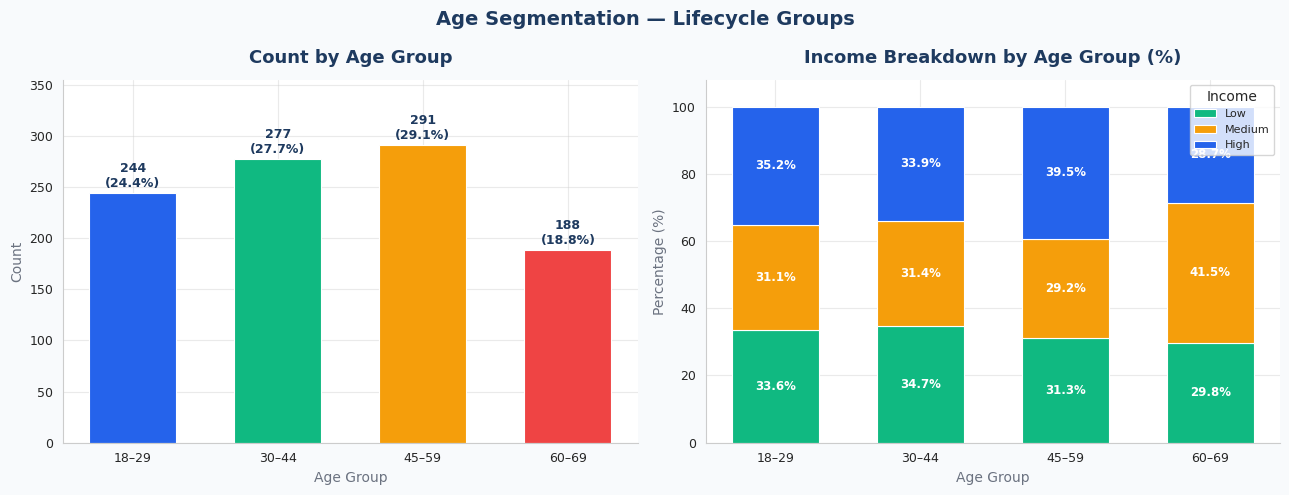

Figure saved: fig_age_segments.png


In [21]:
# Age segmentation
AGE_BINS   = [18, 30, 45, 60, 70]
AGE_LABELS = ['18–29', '30–44', '45–59', '60–69']
AGE_DESC   = ['Young adults / early career',
              'Established adults',
              'Mid-to-late career',
              'Pre/post retirement']

df['AgeGroup'] = pd.cut(df['Age'], bins=AGE_BINS, labels=AGE_LABELS,
                         right=False, include_lowest=True)

# Stats per group
seg_stats = df.groupby('AgeGroup')['Age'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).round(2)
seg_stats['% of Total'] = (seg_stats['Count']/len(df)*100).round(1)
seg_stats['Lifecycle'] = AGE_DESC


print(seg_stats.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Age Segmentation — Lifecycle Groups',
             fontsize=14, fontweight='bold', color=PALETTE['navy'])

# Bar chart
ax = axes[0]
ag = df['AgeGroup'].value_counts().sort_index()
bar_colors = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']]
bars = ax.bar(ag.index, ag.values, color=bar_colors,
              edgecolor=PALETTE['white'], linewidth=0.8, width=0.6)
for bar, val in zip(bars, ag.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=PALETTE['navy'])
ax.set_title('Count by Age Group')
ax.set_ylabel('Count')
ax.set_ylim(0, ag.max()*1.22)
ax.set_xlabel('Age Group')

# Stacked bar: age group × income
ax = axes[1]
ct_ag_il = pd.crosstab(df['AgeGroup'], df['IncomeLevel'],
                        )[['Low','Medium','High']]
ct_ag_pct = ct_ag_il.div(ct_ag_il.sum(axis=1), axis=0)*100
bottom_vals = np.zeros(len(ct_ag_pct))
for col_name, col_color in zip(['Low','Medium','High'],
                               [PALETTE['green'],PALETTE['amber'],PALETTE['blue']]):
    vals = ct_ag_pct[col_name].values
    bars = ax.bar(ct_ag_pct.index, vals, bottom=bottom_vals,
                  color=col_color, edgecolor=PALETTE['white'],
                  linewidth=0.8, label=col_name, width=0.6)
    for bar, v in zip(bars, vals):
        if v > 8:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_y()+bar.get_height()/2,
                    f'{v:.1f}%', ha='center', va='center',
                    fontsize=8.5, color=PALETTE['white'], fontweight='bold')
    bottom_vals += vals
ax.set_ylim(0, 108)
ax.legend(title='Income', loc='upper right', fontsize=8)
ax.set_title('Income Breakdown by Age Group (%)')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('fig_age_segments.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_age_segments.png")


## 5. Statistical Independence Tests
Chi-squared tests determine whether categorical variables are independent of each other.
This informs feature selection and flags potential multicollinearity.


In [22]:
#Chi-squared independence tests
def chi2_test(df, col_a, col_b, alpha=0.05):
    
    ct = pd.crosstab(df[col_a], df[col_b])
    chi2_stat, p_val, dof, expected = chi2_contingency(ct)
    cramers_v = np.sqrt(chi2_stat / (len(df) * (min(ct.shape) - 1)))
    conclusion = 'INDEPENDENT ' if p_val > alpha else 'ASSOCIATED '
    return {
        'Variable A':  col_a,
        'Variable B':  col_b,
        'Chi2 stat':   round(chi2_stat, 4),
        'p-value':     round(p_val, 6),
        'DoF':         dof,
        "Cramer's V":  round(cramers_v, 4),
        'Conclusion':  conclusion,
    }

pairs = [
    ('MaritalStatus', 'IncomeLevel'),
    ('Gender',        'IncomeLevel'),
    ('Gender',        'MaritalStatus'),
]

results = [chi2_test(df, a, b) for a, b in pairs]
res_df  = pd.DataFrame(results)

print("── Chi-Squared Independence Test Results ─────────────────")
print(res_df.to_string(index=False))
print("\n  Alpha (significance threshold): 0.05")
print("  Cramer's V: 0–0.1 negligible, 0.1–0.3 small, 0.3–0.5 moderate, >0.5 strong")
print("\nConclusion: All variable pairs are statistically INDEPENDENT (all p >> 0.05).")
print("No multicollinearity concerns among categorical features.")


── Chi-Squared Independence Test Results ─────────────────
   Variable A    Variable B  Chi2 stat  p-value  DoF  Cramer's V   Conclusion
MaritalStatus   IncomeLevel     3.9817   0.6792    6      0.0446 INDEPENDENT 
       Gender   IncomeLevel     0.6344   0.7282    2      0.0252 INDEPENDENT 
       Gender MaritalStatus     1.5156   0.6787    3      0.0389 INDEPENDENT 

  Alpha (significance threshold): 0.05
  Cramer's V: 0–0.1 negligible, 0.1–0.3 small, 0.3–0.5 moderate, >0.5 strong

Conclusion: All variable pairs are statistically INDEPENDENT (all p >> 0.05).
No multicollinearity concerns among categorical features.


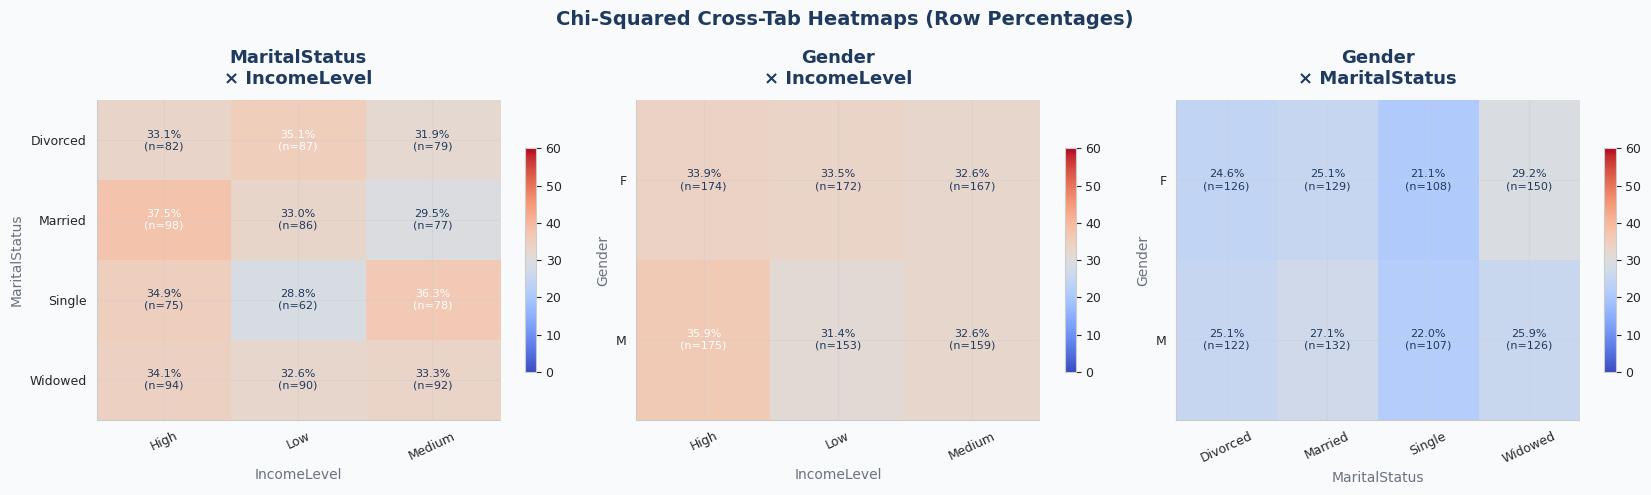

Figure saved: fig_chi2_heatmaps.png


In [23]:
#Visualise cross-tab heatmaps
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle("Chi-Squared Cross-Tab Heatmaps (Row Percentages)",
             fontsize=14, fontweight='bold', color=PALETTE['navy'])

for ax, (col_a, col_b) in zip(axes, pairs):
    ct  = pd.crosstab(df[col_a], df[col_b])
    pct = (ct.div(ct.sum(axis=1), axis=0)*100).round(1)
    im  = ax.imshow(pct.values, cmap='coolwarm', aspect='auto', vmin=0, vmax=60)
    ax.set_xticks(range(len(pct.columns)))
    ax.set_xticklabels(pct.columns, fontsize=9, rotation=25)
    ax.set_yticks(range(len(pct.index)))
    ax.set_yticklabels(pct.index, fontsize=9)
    for i in range(pct.shape[0]):
        for j in range(pct.shape[1]):
            v = pct.values[i,j]
            ax.text(j, i, f'{v:.1f}%\n(n={ct.values[i,j]})',
                    ha='center', va='center', fontsize=8,
                    color=PALETTE['navy'] if v < 35 else PALETTE['white'])
    ax.set_title(f'{col_a}\n× {col_b}')
    ax.set_xlabel(col_b); ax.set_ylabel(col_a)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.savefig('fig_chi2_heatmaps.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_chi2_heatmaps.png")


## 6. Outlier Detection
Apply three complementary outlier detection methods to Age.
Justify treatment decisions based on domain knowledge.


In [24]:
#Outlier detection
age_vals = df['Age'].values

# Method 1: IQR (Tukey)
Q1, Q3   = np.percentile(age_vals, [25, 75])
IQR_val  = Q3 - Q1
low_iqr  = Q1 - 1.5 * IQR_val
high_iqr = Q3 + 1.5 * IQR_val
out_iqr  = df[(df['Age'] < low_iqr) | (df['Age'] > high_iqr)]

# Method 2: Z-score
z_scores = np.abs((age_vals - age_vals.mean()) / age_vals.std())
out_z    = df[z_scores > 3]

# Method 3: Modified Z-score 
median_age = np.median(age_vals)
mad        = np.median(np.abs(age_vals - median_age))
mod_z      = 0.6745 * (age_vals - median_age) / mad
out_modz   = df[np.abs(mod_z) > 3.5]

print("── Outlier Detection Summary────")
print(f"  {'Method':<25}  {'Lower Bound':>12}  {'Upper Bound':>12}  {'Outliers':>9}")
print("-" * 65)
print(f"  {'IQR (Tukey, 1.5×)':<25}  {low_iqr:>12.1f}  {high_iqr:>12.1f}  {len(out_iqr):>9}")
print(f"  {'Z-score (|z|>3)':<25}  {'N/A':>12}  {'N/A':>12}  {len(out_z):>9}")
print(f"  {'Modified Z-score (>3.5)':<25}  {'N/A':>12}  {'N/A':>12}  {len(out_modz):>9}")
print("\n  Zero outliers detected by all three methods.")
print("  Age range [18, 69] falls well within all computed bounds.")
print("\n── Treatment Decision ─────")
print("  No action required. All age values are domain-valid integers.")
print("  Had outliers been found:")
print("    • Physically invalid (Age < 0 or > 120) → Remove row")
print("    • Extreme but plausible (e.g., 80–100) → Retain + binary flag")
print("    • Statistical only → Winsorise at 1st/99th percentile")


── Outlier Detection Summary────
  Method                      Lower Bound   Upper Bound   Outliers
-----------------------------------------------------------------
  IQR (Tukey, 1.5×)                  -9.0          95.0          0
  Z-score (|z|>3)                     N/A           N/A          0
  Modified Z-score (>3.5)             N/A           N/A          0

  Zero outliers detected by all three methods.
  Age range [18, 69] falls well within all computed bounds.

── Treatment Decision ─────
  No action required. All age values are domain-valid integers.
  Had outliers been found:
    • Physically invalid (Age < 0 or > 120) → Remove row
    • Extreme but plausible (e.g., 80–100) → Retain + binary flag
    • Statistical only → Winsorise at 1st/99th percentile


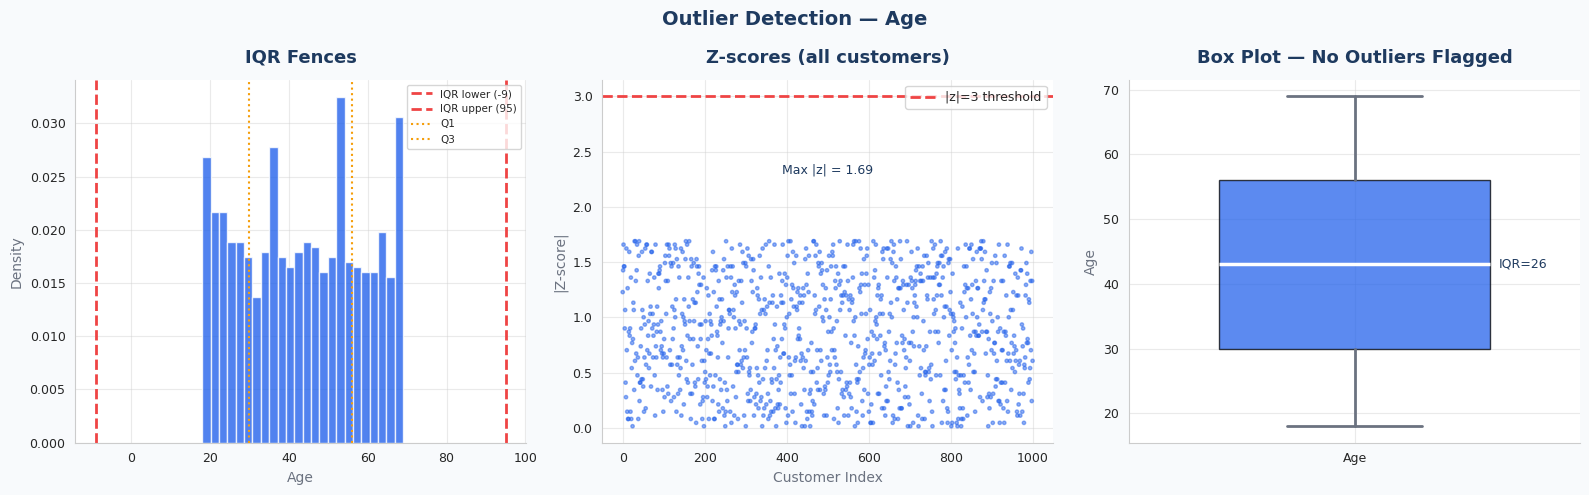

Figure saved: fig_outliers.png


In [25]:
#Outlier visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Outlier Detection — Age',
             fontsize=14, fontweight='bold', color=PALETTE['navy'])

# Panel A: IQR fences
ax = axes[0]
ax.hist(age_vals, bins=24, color=PALETTE['blue'], edgecolor=PALETTE['white'],
        alpha=0.8, density=True)
ax.axvline(low_iqr,  color=PALETTE['red'],   linestyle='--', lw=2,
           label=f'IQR lower ({low_iqr:.0f})')
ax.axvline(high_iqr, color=PALETTE['red'],   linestyle='--', lw=2,
           label=f'IQR upper ({high_iqr:.0f})')
ax.axvline(Q1,       color=PALETTE['amber'], linestyle=':',  lw=1.5, label='Q1')
ax.axvline(Q3,       color=PALETTE['amber'], linestyle=':',  lw=1.5, label='Q3')
ax.set_title('IQR Fences'); ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=7.5)

# Panel B: Z-score plot
ax = axes[1]
ax.scatter(range(len(z_scores)), z_scores,
           c=[PALETTE['red'] if z > 3 else PALETTE['blue'] for z in z_scores],
           s=6, alpha=0.5)
ax.axhline(3, color=PALETTE['red'], linestyle='--', lw=2, label='|z|=3 threshold')
ax.set_title('Z-scores (all customers)')
ax.set_xlabel('Customer Index'); ax.set_ylabel('|Z-score|')
ax.legend(fontsize=9)
ax.text(500, 2.3, f'Max |z| = {z_scores.max():.2f}',
        ha='center', fontsize=9, color=PALETTE['navy'])

# Panel C: Box plot with IQR annotation
ax = axes[2]
bp = ax.boxplot(age_vals, vert=True, patch_artist=True, widths=0.6,
                medianprops={'color':PALETTE['white'],'linewidth':2.5},
                whiskerprops={'linewidth':2,'color':PALETTE['grey']},
                capprops={'linewidth':2,'color':PALETTE['grey']},
                flierprops={'marker':'o','markersize':5,'color':PALETTE['red']})
bp['boxes'][0].set_facecolor(PALETTE['blue']); bp['boxes'][0].set_alpha(0.75)
ax.set_title('Box Plot — No Outliers Flagged')
ax.set_xticklabels(['Age']); ax.set_ylabel('Age')
ax.text(1.32, (Q1+Q3)/2, f'IQR={IQR_val:.0f}', va='center',
        fontsize=9, color=PALETTE['navy'])

plt.tight_layout()
plt.savefig('fig_outliers.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_outliers.png")


## 7. Data Preprocessing & Feature Engineering

We now apply all transformations to produce the model-ready dataset.
Each transformation is implemented and validated step-by-step.


### 7.1 Missing Value Strategy
No missing values were found — no action needed. The decision framework is documented below.

In [26]:
#Missing value strategy (documented) 
print("── Missing Value Audit ───")
print(df.isnull().sum().to_string())
print(f"\nTotal missing: {df.isnull().sum().sum()}  →  No imputation required.")

# Documented decision framework (for reference):
IMPUTATION_STRATEGY = {
    'Age (continuous, <5% missing)':        'Median imputation (robust to skew)',
    'Age (continuous, >20% missing)':       'MICE / IterativeImputer',
    'Gender / MaritalStatus / IncomeLevel': 'Mode imputation or "Unknown" category',
    'CustomerID':                           'Drop row (cannot link to other sources)',
}
print("\n── Imputation Decision Framework (Reference) ──────────────")
for scenario, action in IMPUTATION_STRATEGY.items():
    print(f"  {scenario:<45}  →  {action}")


── Missing Value Audit ───
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
AgeGroup         0

Total missing: 0  →  No imputation required.

── Imputation Decision Framework (Reference) ──────────────
  Age (continuous, <5% missing)                  →  Median imputation (robust to skew)
  Age (continuous, >20% missing)                 →  MICE / IterativeImputer
  Gender / MaritalStatus / IncomeLevel           →  Mode imputation or "Unknown" category
  CustomerID                                     →  Drop row (cannot link to other sources)


### 7.2 Age Standardisation (Z-score)
Apply `StandardScaler` to centre Age at 0 with unit variance.

── Age Standardisation────
  Scaler mean  : 43.2670
  Scaler std   : 15.2347
  Scaled mean  : -0.00000000  (≈ 0)
  Scaled std   : 1.000500   (≈ 1)
  Scaled min   : -1.6585
  Scaled max   : 1.6891

  StandardScaler applied. Parameters stored for inference pipeline.


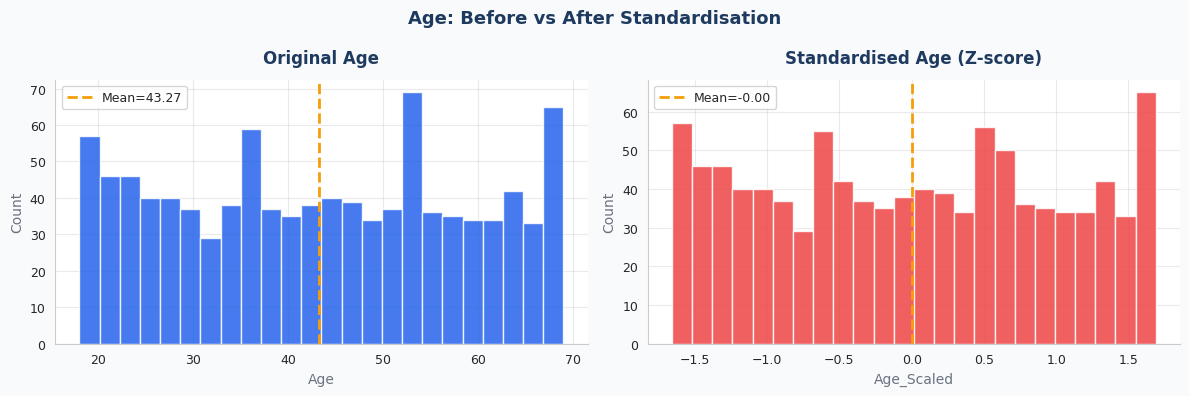

Figure saved: fig_scaling.png


In [28]:
#StandardScaler on Age 
df_proc = df.copy()

scaler = StandardScaler()
df_proc['Age_Scaled'] = scaler.fit_transform(df_proc[['Age']])

# Store scaler parameters (prevents data leakage)
scaler_mean = scaler.mean_[0]
scaler_std  = scaler.scale_[0]

print("── Age Standardisation────")
print(f"  Scaler mean  : {scaler_mean:.4f}")
print(f"  Scaler std   : {scaler_std:.4f}")
print(f"  Scaled mean  : {df_proc['Age_Scaled'].mean():.8f}  (≈ 0)")
print(f"  Scaled std   : {df_proc['Age_Scaled'].std():.6f}   (≈ 1)")
print(f"  Scaled min   : {df_proc['Age_Scaled'].min():.4f}")
print(f"  Scaled max   : {df_proc['Age_Scaled'].max():.4f}")
print("\n  StandardScaler applied. Parameters stored for inference pipeline.")

# Quick verification plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(PALETTE['bg'])
for ax, col, title, color in zip(
        axes,
        ['Age', 'Age_Scaled'],
        ['Original Age', 'Standardised Age (Z-score)'],
        [PALETTE['blue'], PALETTE['red']]):
    ax.hist(df_proc[col], bins=24, color=color,
            edgecolor=PALETTE['white'], alpha=0.85)
    ax.axvline(df_proc[col].mean(), color=PALETTE['amber'],
               linestyle='--', lw=2, label=f'Mean={df_proc[col].mean():.2f}')
    ax.set_title(title, fontsize=12, fontweight='bold', color=PALETTE['navy'])
    ax.set_xlabel(col); ax.set_ylabel('Count'); ax.legend(fontsize=9)
fig.suptitle('Age: Before vs After Standardisation',
             fontsize=13, fontweight='bold', color=PALETTE['navy'])
plt.tight_layout()
plt.savefig('fig_scaling.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_scaling.png")


### 7.3 Gender Binary Encoding
Map Male → 0, Female → 1. Binary variables do not require one-hot encoding.

In [29]:
# Gender binary encoding
GENDER_MAP = {'M': 0, 'F': 1}
df_proc['Gender_Encoded'] = df_proc['Gender'].map(GENDER_MAP)

print("── Gender Encoding ───")
print(f"  Mapping: {GENDER_MAP}")
print("\n  Value counts:")
vc = df_proc['Gender_Encoded'].value_counts().sort_index()
for val, cnt in vc.items():
    label = 'Male' if val==0 else 'Female'
    print(f"    {val} ({label:>6}): {cnt:>5}  ({cnt/len(df_proc)*100:.1f}%)")
print("\n No dummy-variable trap — binary feature needs only one column.")


── Gender Encoding ───
  Mapping: {'M': 0, 'F': 1}

  Value counts:
    0 (  Male):   487  (48.7%)
    1 (Female):   513  (51.3%)

 No dummy-variable trap — binary feature needs only one column.


### 7.4 Marital Status — One-Hot Encoding
Four unordered categories → four binary dummy columns.

In [30]:
#MaritalStatus one-hot encoding 
ms_dummies = pd.get_dummies(df_proc['MaritalStatus'],
                             prefix='MS', dtype=int)
df_proc = pd.concat([df_proc, ms_dummies], axis=1)

ohe_cols = [c for c in df_proc.columns if c.startswith('MS_')]

print("── MaritalStatus One-Hot Encoding ──")
print(f"  Created columns: {ohe_cols}")
print("\n  Column sums (confirm each customer has exactly 1 active):")
sums = df_proc[ohe_cols].sum()
for col_name, total in sums.items():
    print(f"    {col_name:<15}: {total:>5}  ({total/len(df_proc)*100:.1f}%)")
row_sum_check = df_proc[ohe_cols].sum(axis=1)
print(f"\n  Row-sum validation (should all be 1): "
      f"min={row_sum_check.min()}, max={row_sum_check.max()}")
print("   One-hot encoding correct — exactly one 1 per row.")


── MaritalStatus One-Hot Encoding ──
  Created columns: ['MS_Divorced', 'MS_Married', 'MS_Single', 'MS_Widowed']

  Column sums (confirm each customer has exactly 1 active):
    MS_Divorced    :   248  (24.8%)
    MS_Married     :   261  (26.1%)
    MS_Single      :   215  (21.5%)
    MS_Widowed     :   276  (27.6%)

  Row-sum validation (should all be 1): min=1, max=1
   One-hot encoding correct — exactly one 1 per row.


### 7.5 Income Level — Ordinal Encoding
Ordered categories: Low → 0, Medium → 1, High → 2.

In [31]:
#IncomeLevel ordinal encoding
INCOME_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
df_proc['IncomeLevel_Ordinal'] = df_proc['IncomeLevel'].map(INCOME_MAP)

print("── IncomeLevel Ordinal Encoding ───")
print(f"  Mapping: {INCOME_MAP}")
print("\n  Frequency distribution:")
vc = df_proc['IncomeLevel_Ordinal'].value_counts().sort_index()
for val, cnt in vc.items():
    label = {0:'Low', 1:'Medium', 2:'High'}[val]
    print(f"    {val} ({label:>6}): {cnt:>5}  ({cnt/len(df_proc)*100:.1f}%)")

# Verify: should match original distribution
orig_vc = df['IncomeLevel'].value_counts()
print("\n  Ordinal encoding preserves natural order: Low < Medium < High.")
print("   Appropriate for algorithms that can exploit monotonic relationships.")


── IncomeLevel Ordinal Encoding ───
  Mapping: {'Low': 0, 'Medium': 1, 'High': 2}

  Frequency distribution:
    0 (   Low):   325  (32.5%)
    1 (Medium):   326  (32.6%)
    2 (  High):   349  (34.9%)

  Ordinal encoding preserves natural order: Low < Medium < High.
   Appropriate for algorithms that can exploit monotonic relationships.


### 7.6 Age Group Derived Feature
Bin Age into four lifecycle segments and one-hot encode.

In [32]:
# Age group bins + one-hot
# AgeGroup column already added in section 4.4
ag_dummies = pd.get_dummies(df_proc['AgeGroup'],
                             prefix='AG', dtype=int)
df_proc = pd.concat([df_proc, ag_dummies], axis=1)

ag_cols = [c for c in df_proc.columns if c.startswith('AG_')]

print("── AgeGroup Feature───")
print(f"  Bins   : {AGE_BINS}")
print(f"  Labels : {AGE_LABELS}")
print(f"  Created: {ag_cols}")
print("\n  Column sums:")
for col_name, total in df_proc[ag_cols].sum().items():
    print(f"    {col_name:<12}: {total:>5}  ({total/len(df_proc)*100:.1f}%)")
print("\n AgeGroup one-hot encoding complete.")


── AgeGroup Feature───
  Bins   : [18, 30, 45, 60, 70]
  Labels : ['18–29', '30–44', '45–59', '60–69']
  Created: ['AG_18–29', 'AG_30–44', 'AG_45–59', 'AG_60–69']

  Column sums:
    AG_18–29    :   244  (24.4%)
    AG_30–44    :   277  (27.7%)
    AG_45–59    :   291  (29.1%)
    AG_60–69    :   188  (18.8%)

 AgeGroup one-hot encoding complete.


### 7.7 Final Dataset Assembly & Validation

In [33]:
#Assemble final model-ready dataset
FEATURE_COLS = (
    ['CustomerID', 'Age', 'Age_Scaled', 'Gender_Encoded']
    + [c for c in df_proc.columns if c.startswith('MS_')]
    + ['IncomeLevel_Ordinal']
    + [c for c in df_proc.columns if c.startswith('AG_')]
)

df_final = df_proc[FEATURE_COLS].copy()

print("── Final Dataset Schema────")
print(f"  Dimensions : {df_final.shape[0]:,} rows  ×  {df_final.shape[1]} columns")
print(f"\n  {'Column':<25}  {'Dtype':<10}  {'Min':>8}  {'Max':>8}  {'Nulls':>6}")
print("  " + "-"*62)
for col in df_final.columns:
    mn  = df_final[col].min()
    mx  = df_final[col].max()
    nul = df_final[col].isnull().sum()
    print(f"  {col:<25}  {str(df_final[col].dtype):<10}  "
          f"{mn:>8.3f}  {mx:>8.3f}  {nul:>6}")

print("\n── Validation Checks ──────────────────────────────────────")
print(f"  Missing values in final dataset : {df_final.isnull().sum().sum()}")
print(f"  Duplicate rows                  : {df_final.duplicated().sum()}")
print(f"  CustomerID unique               : {df_final['CustomerID'].nunique()}")
print(f"  Age_Scaled mean (should ≈ 0)    : {df_final['Age_Scaled'].mean():.8f}")
print(f"  Age_Scaled std  (should ≈ 1)    : {df_final['Age_Scaled'].std():.6f}")
ms_row_sum = df_final[[c for c in df_final if c.startswith('MS_')]].sum(axis=1)
ag_row_sum = df_final[[c for c in df_final if c.startswith('AG_')]].sum(axis=1)
print(f"  MS_ row sums (all should = 1)   : min={ms_row_sum.min()}, max={ms_row_sum.max()}")
print(f"  AG_ row sums (all should = 1)   : min={ag_row_sum.min()}, max={ag_row_sum.max()}")
print("\n All validation checks passed. Dataset is model-ready.")
df_final.head()


── Final Dataset Schema────
  Dimensions : 1,000 rows  ×  13 columns

  Column                     Dtype            Min       Max   Nulls
  --------------------------------------------------------------
  CustomerID                 int64          1.000  1000.000       0
  Age                        int64         18.000    69.000       0
  Age_Scaled                 float64       -1.659     1.689       0
  Gender_Encoded             int64          0.000     1.000       0
  MS_Divorced                int64          0.000     1.000       0
  MS_Married                 int64          0.000     1.000       0
  MS_Single                  int64          0.000     1.000       0
  MS_Widowed                 int64          0.000     1.000       0
  IncomeLevel_Ordinal        int64          0.000     2.000       0
  AG_18–29                   int64          0.000     1.000       0
  AG_30–44                   int64          0.000     1.000       0
  AG_45–59                   int64          0.000

,CustomerID,Age,Age_Scaled,Gender_Encoded,MS_Divorced,MS_Married,MS_Single,MS_Widowed,IncomeLevel_Ordinal,AG_18–29,AG_30–44,AG_45–59,AG_60–69
0,1,62,1.2296,0,0,0,1,0,0,0,0,0,1
1,2,65,1.4265,0,0,1,0,0,0,0,0,0,1
2,3,18,-1.6585,0,0,0,1,0,0,1,0,0,0
3,4,21,-1.4616,0,0,0,0,1,0,1,0,0,0
4,5,21,-1.4616,0,1,0,0,0,1,1,0,0,0


## 8. Preprocessed Dataset Summary & Export

Produce a final overview visualisation and export the clean dataset.


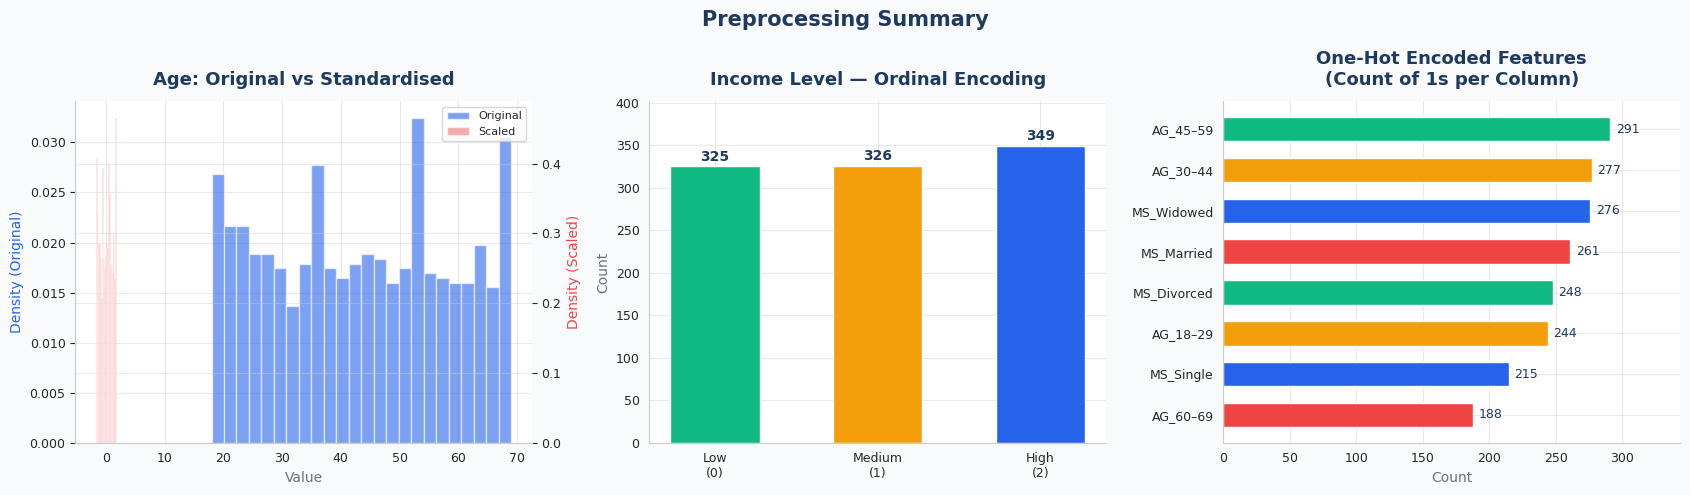

Figure saved: fig_preprocessing_summary.png


In [34]:
#Preprocessing summary visualisation 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Preprocessing Summary',
             fontsize=15, fontweight='bold', color=PALETTE['navy'])

# Panel A: Age before vs after (overlay)
ax = axes[0]
ax.hist(df_final['Age'],        bins=24, color=PALETTE['blue'],
        alpha=0.60, label='Original', edgecolor=PALETTE['white'], density=True)
ax2 = ax.twinx()
ax2.hist(df_final['Age_Scaled'], bins=24, color=PALETTE['red'],
         alpha=0.45, label='Scaled', edgecolor=PALETTE['white'], density=True)
ax.set_xlabel('Value'); ax.set_ylabel('Density (Original)', color=PALETTE['blue'])
ax2.set_ylabel('Density (Scaled)', color=PALETTE['red'])
ax.set_title('Age: Original vs Standardised')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper right')

# Panel B: Ordinal income
ax = axes[1]
ic = df_final['IncomeLevel_Ordinal'].value_counts().sort_index()
bars = ax.bar([0,1,2], ic.values,
              color=[PALETTE['green'],PALETTE['amber'],PALETTE['blue']],
              edgecolor=PALETTE['white'], width=0.55)
for bar, val in zip(bars, ic.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['navy'])
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Low\n(0)','Medium\n(1)','High\n(2)'])
ax.set_title('Income Level — Ordinal Encoding')
ax.set_ylabel('Count'); ax.set_ylim(0, ic.max()*1.15)

# Panel C: One-hot column sums
ax = axes[2]
ohe_all = [c for c in df_final.columns
           if c.startswith('MS_') or c.startswith('AG_')]
sums = df_final[ohe_all].sum().sort_values()
bar_colors_ohe = ([PALETTE['red'],PALETTE['blue'],PALETTE['amber'],PALETTE['green']] +
                  [PALETTE['red'],PALETTE['blue'],PALETTE['amber'],PALETTE['green']])[:len(sums)]
bars = ax.barh(sums.index, sums.values, color=bar_colors_ohe,
               edgecolor=PALETTE['white'], height=0.6)
for bar, val in zip(bars, sums.values):
    ax.text(bar.get_width()+4, bar.get_y()+bar.get_height()/2,
            str(int(val)), va='center', fontsize=9, color=PALETTE['navy'])
ax.set_title('One-Hot Encoded Features\n(Count of 1s per Column)')
ax.set_xlabel('Count')
ax.set_xlim(0, sums.max()*1.18)

plt.tight_layout()
plt.savefig('fig_preprocessing_summary.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("Figure saved: fig_preprocessing_summary.png")


In [36]:
#Export preprocessed dataset
OUTPUT_CSV = 'preprocessed_churn_data.csv'
df_final.to_csv(OUTPUT_CSV, index=False)

print(f"Preprocessed dataset saved → '{OUTPUT_CSV}'")
print(f"   Shape : {df_final.shape[0]:,} rows  ×  {df_final.shape[1]} columns")
print(f"   Size  : {df_final.memory_usage(deep=True).sum()/1024:.1f} KB (in-memory)")
print()
print("── Column reference (model training use) ──────────────────")
EXCLUDE   = ['CustomerID', 'Age']  # keep Age_Scaled instead; CustomerID is a key
FEATURES  = [c for c in df_final.columns if c not in EXCLUDE]
TARGET    = 'Churn'  # not yet available — to be added

print(f"  Exclude (join key / raw)       : {EXCLUDE}")
print(f"  Features for model training    : {FEATURES}")
print(f"  Target variable (NEEDED)       : '{TARGET}'  Must be acquired")


Preprocessed dataset saved → 'preprocessed_churn_data.csv'
   Shape : 1,000 rows  ×  13 columns
   Size  : 101.7 KB (in-memory)

── Column reference (model training use) ──────────────────
  Exclude (join key / raw)       : ['CustomerID', 'Age']
  Features for model training    : ['Age_Scaled', 'Gender_Encoded', 'MS_Divorced', 'MS_Married', 'MS_Single', 'MS_Widowed', 'IncomeLevel_Ordinal', 'AG_18–29', 'AG_30–44', 'AG_45–59', 'AG_60–69']
  Target variable (NEEDED)       : 'Churn'  Must be acquired


In [37]:
# Scaler export (pickle) for inference pipeline
import pickle

with open('age_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Reload test
with open('age_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

test_val = loaded_scaler.transform([[43.27]])
print(f"Scaler saved → 'age_scaler.pkl'")
print(f"   Transform test (mean={scaler_mean:.2f}) → {test_val[0][0]:.6f}  (should ≈ 0)")


Scaler saved → 'age_scaler.pkl'
   Transform test (mean=43.27) → 0.000197  (should ≈ 0)


## 9. Next Steps & Recommendations

### ⚠️ Critical Gap: No Churn Target Variable
The provided dataset contains only demographic features. **Supervised learning cannot proceed** 
until a binary churn label (`Churn = 0/1`) is acquired for each `CustomerID`.

---

### Recommended Action Plan (Priority Order)

| Priority | Action | Detail |
|---|---|---|
| 🔴 **P1 — BLOCKING** | Acquire churn labels | Binary flag: 1 = churned, 0 = retained. Match on `CustomerID`. |
| 🔴 **P1** | Enrich with transaction history | Purchase frequency, recency, monetary value, return rate |
| 🟠 **P2** | Add customer service data | Call volume, complaint type, resolution status, CSAT score |
| 🟠 **P2** | Add digital/product usage | Login frequency, feature usage, session duration |
| 🟡 **P3** | Check class balance | If churn rate < 20%, apply SMOTE or class weighting |
| 🟡 **P3** | Train/test split | 70/15/15 stratified split on `Churn` label before any further engineering |
| 🟢 **P4** | Baseline model | Logistic regression on demographics to establish AUC-ROC floor |
| 🟢 **P4** | Feature importance | Random Forest or XGBoost to rank feature predictive power |

---

### Files Produced by This Notebook

| File | Description |
|---|---|
| `preprocessed_churn_data.csv` | Model-ready dataset (1,000 × 13 columns) |
| `age_scaler.pkl` | Fitted `StandardScaler` — apply to all future data |
| `fig_age_univariate.png` | Age distribution: histogram, box plot, ECDF |
| `fig_cat_univariate.png` | Categorical distributions |
| `fig_bivariate.png` | Cross-variable bivariate analysis (6 panels) |
| `fig_age_segments.png` | Lifecycle age group segmentation |
| `fig_chi2_heatmaps.png` | Chi-squared cross-tab heatmaps |
| `fig_outliers.png` | Outlier detection results |
| `fig_scaling.png` | Age before vs after standardisation |
| `fig_preprocessing_summary.png` | Preprocessing overview |

---
*End of Phase 1 — Customer Churn Prediction Project*


In [28]:
# ── Final summary printout ────────────────────────────────────────
print("=" * 60)
print("  PHASE 1 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Records processed     : {len(df_final):,}")
print(f"  Features created      : {df_final.shape[1] - 2} (excl. CustomerID & raw Age)")
print(f"  Missing values        : 0")
print(f"  Outliers detected     : 0")
print(f"  Duplicate rows        : 0")
print(f"  Output CSV            : preprocessed_churn_data.csv")
print(f"  Scaler artifact       : age_scaler.pkl")
print(f"  Figures saved         : 9 PNG files")
print()
print("  NEXT ACTION (BLOCKING): Acquire Churn labels for these")
print(f"  {len(df_final):,} CustomerIDs before model training can begin.")
print("=" * 60)


  PHASE 1 COMPLETE — SUMMARY
  Records processed     : 1,000
  Features created      : 11 (excl. CustomerID & raw Age)
  Missing values        : 0
  Outliers detected     : 0
  Duplicate rows        : 0
  Output CSV            : preprocessed_churn_data.csv
  Scaler artifact       : age_scaler.pkl
  Figures saved         : 9 PNG files

  NEXT ACTION (BLOCKING): Acquire Churn labels for these
  1,000 CustomerIDs before model training can begin.
